# Modeling

In [27]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

In [28]:
TRAIN_PATH = Path("../data/processed/train.csv")
VALIDATION_PATH = Path("../data/processed/validation.csv")
TEST_PATH = Path("../data/processed/test.csv")

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

train_df["DateTime"] = pd.to_datetime(train_df["DateTime"])
val_df["DateTime"] = pd.to_datetime(val_df["DateTime"])
test_df["DateTime"] = pd.to_datetime(test_df["DateTime"])

In [29]:
feature_columns = [
    "PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
    "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "day_of_week", "is_weekend",
]

target_columns = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]

In [30]:
split_lengths = {
    "train": len(train_df),
    "validation": len(val_df),
    "test": len(test_df),
}

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
feature_frame = all_df[["DateTime"] + feature_columns].copy()
missing_before_ffill = feature_frame[feature_columns].isna().sum()
feature_frame[feature_columns] = feature_frame[feature_columns].ffill()
missing_after_ffill = feature_frame[feature_columns].isna().sum()

display(missing_before_ffill.sort_values(ascending=False).to_frame("before_ffill"))
display(missing_after_ffill.sort_values(ascending=False).to_frame("after_ffill"))

,before_ffill
PT08.S1(CO),366
PT08.S2(NMHC),366
PT08.S3(NOx),366
PT08.S4(NO2),366
PT08.S5(O3),366
T,366
RH,366
AH,366
hour_sin,0
hour_cos,0


,after_ffill
PT08.S1(CO),0
PT08.S2(NMHC),0
PT08.S3(NOx),0
PT08.S4(NO2),0
PT08.S5(O3),0
T,0
RH,0
AH,0
hour_sin,0
hour_cos,0


In [31]:
train_features = feature_frame.iloc[:split_lengths["train"]].copy().reset_index(drop=True)
validation_features = feature_frame.iloc[
    split_lengths["train"]:split_lengths["train"] + split_lengths["validation"]
].copy().reset_index(drop=True)
test_features = feature_frame.iloc[
    split_lengths["train"] + split_lengths["validation"]:
].copy().reset_index(drop=True)

X_train_filled = train_features[feature_columns]
X_validation_filled = validation_features[feature_columns]
X_test_filled = test_features[feature_columns]

In [32]:
def make_pipeline(estimator):
    return Pipeline([
        ("median_imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", estimator)
    ])

def make_searches():
    return {
        "Ridge": (
            make_pipeline(Ridge()),
            {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
        ),
        "RandomForest": (
            make_pipeline(RandomForestRegressor(random_state=42, n_jobs=-1)),
            {
                "model__n_estimators": [200, 400],
                "model__max_depth": [None, 10, 20],
                "model__min_samples_leaf": [1, 2, 5],
                "model__max_features": [1.0, "sqrt"]
            }
        ),
        "XGBoost": (
            make_pipeline(XGBRegressor(
                objective="reg:squarederror",
                eval_metric="rmse",
                random_state=42,
                n_jobs=-1
            )),
            {
                "model__n_estimators": [200, 400],
                "model__learning_rate": [0.03, 0.1],
                "model__max_depth": [3, 6],
                "model__subsample": [0.8, 1.0],
                "model__colsample_bytree": [0.8, 1.0]
            }
        )
    }

def regression_metrics(y_true, y_pred):
    return {
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }

In [33]:
cv = TimeSeriesSplit(n_splits=4)
primary_scoring = "neg_root_mean_squared_error"

In [34]:
validation_results = []
best_models = {}
validation_predictions = {}

def valid_target_data(features, frame, target):
    mask = frame[target].notna()
    X = features.loc[mask, feature_columns].copy()
    y = frame.loc[mask, target].copy()
    return X, y

In [35]:
for target in target_columns:
    X_train, y_train, = valid_target_data(X_train_filled, train_df, target)
    X_validation, y_validation = valid_target_data(X_validation_filled, val_df, target)

    for model_name, (pipeline, parameter_space) in make_searches().items():
        search_class = GridSearchCV if model_name == "Ridge" else RandomizedSearchCV
        search_kwargs = {
            "estimator": pipeline,
            "scoring": primary_scoring,
            "cv": cv,
            "refit": True,
            "n_jobs": 1,
            "error_score": "raise"
        }
        if model_name == "Ridge":
            search_kwargs["param_grid"] = parameter_space
        else:
            search_kwargs["param_distributions"] = parameter_space
            search_kwargs.update({"n_iter": 8, "random_state": 42})

        search = search_class(**search_kwargs)
        search.fit(X_train, y_train)
        validation_pred = search.predict(X_validation)
        metrics = regression_metrics(y_validation, validation_pred)

        validation_results.append({
            "target": target,
            "model": model_name,
            "cv_rmse": -search.best_score_,
            "validation_rmse": metrics["rmse"],
            "validation_mae": metrics["mae"],
            "validation_r2": metrics["r2"],
            "best_params": search.best_params_,
        })
        best_models[(target, model_name)] = search
        validation_predictions[(target, model_name)] = (y_validation.copy(), validation_pred)


In [36]:
validation_results_df = pd.DataFrame(validation_results)
best_rows = (
    validation_results_df
    .sort_values(["target", "cv_rmse"])
    .groupby("target", as_index=False)
    .first()
)
display(best_rows.drop(columns=["best_params"]))

selected_models = {
    row.target: best_models[(row.target, row.model)]
    for row in best_rows.itertuples()
}

,target,model,cv_rmse,validation_rmse,validation_mae,validation_r2
0,C6H6(GT),RandomForest,0.295540,0.072696,0.015001,0.999896
1,CO(GT),XGBoost,0.416071,0.966530,0.611806,0.641242
2,NO2(GT),XGBoost,22.484346,30.233046,22.666350,0.589049
3,NOx(GT),Ridge,90.914220,132.321919,86.593644,0.724108


In [38]:
final_results = []
final_predictions = {}

for target in target_columns:
    train_mask = train_df[target].notna()
    validation_mask = val_df[target].notna()
    test_mask = test_df[target].notna()

    X_train_valid = pd.concat([
        X_train_filled.loc[train_mask, feature_columns],
        X_validation_filled.loc[validation_mask, feature_columns],
    ], ignore_index=True)
    y_train_valid = pd.concat([
        train_df.loc[train_mask, target],
        val_df.loc[validation_mask, target],
    ], ignore_index=True)
    X_test_target = X_test_filled.loc[test_mask, feature_columns]
    y_test_target = test_df.loc[test_mask, target].reset_index(drop=True)

    selected_row = best_rows.loc[best_rows["target"] == target].iloc[0]
    selected_model_name = selected_row["model"]
    selected_search = selected_models[target]

    final_pipeline = clone(selected_search.best_estimator_)
    final_pipeline.fit(X_train_valid, y_train_valid)
    test_pred = final_pipeline.predict(X_test_target)
    metrics = regression_metrics(y_test_target, test_pred)
    final_results.append(
        {
            "target": target,
            "best_model": selected_model_name,
            "test_rmse": metrics["rmse"],
            "test_mae": metrics["mae"],
            "test_r2": metrics["r2"],
            "test_rows": len(y_test_target),
        }
    )
    final_predictions[target] = (y_test_target.copy(), test_pred)

final_results_df = pd.DataFrame(final_results)
final_results_df

,target,best_model,test_rmse,test_mae,test_r2,test_rows
0,CO(GT),XGBoost,0.722086,0.376870,0.698738,1374
1,C6H6(GT),RandomForest,0.025112,0.011012,0.999983,1327
2,NOx(GT),Ridge,118.493324,71.737549,0.603317,1367
3,NO2(GT),XGBoost,41.716207,31.655456,0.369955,1367


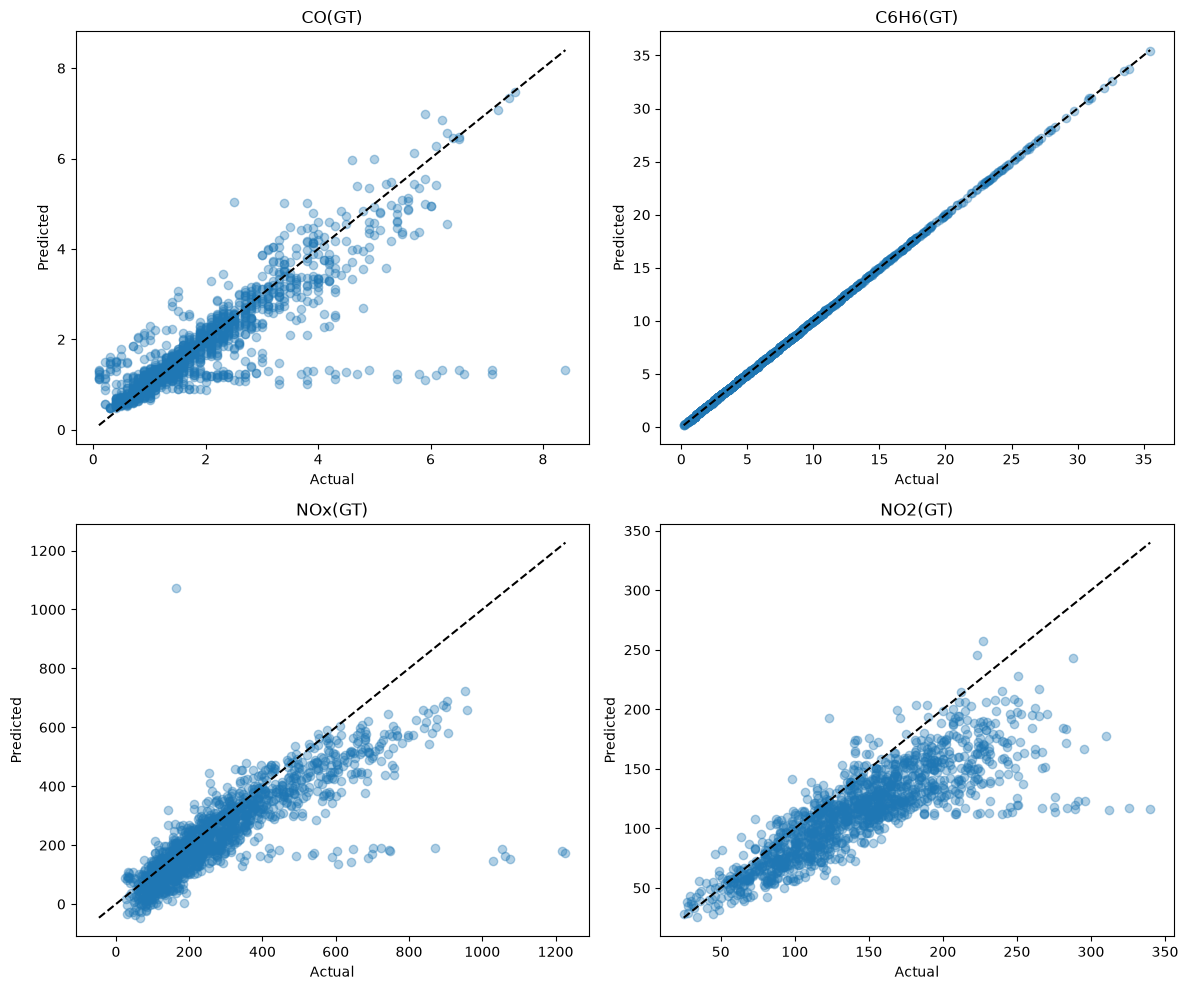

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for axis, target in zip(axes.ravel(), target_columns):
    y_true, y_pred = final_predictions[target]
    axis.scatter(y_true, y_pred, alpha=0.35)
    lower = min(y_true.min(), y_pred.min())
    upper = max(y_true.max(), y_pred.max())
    axis.plot([lower, upper], [lower, upper], linestyle="--", color="black")
    axis.set_title(target)
    axis.set_xlabel("Actual")
    axis.set_ylabel("Predicted")
plt.tight_layout()